# Feature_engineeering

In [106]:
import numpy as np 
import pandas as pd 
import re

In [107]:
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [108]:
pd.reset_option('all')

C:\Users\sarth\AppData\Local\Temp\ipykernel_25644\2786130087.py:1: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
C:\Users\sarth\AppData\Local\Temp\ipykernel_25644\2786130087.py:1: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


In [109]:
df=pd.read_csv('gurgaon_properties_cleaned2_v1.csv')

In [110]:
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features 
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,gls avenue,sector 92,0.21,6953.0,302.00,Carpet area: 302 (28.06 sq.m.),1,1,1,not available,0.0,South-East,1 to 5 Year Old,"['Yaduvanshi Shiksha Niketan Sector- 92', 'Aar...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian..."
1,flat,paras quartier,sector 59,5.90,11028.0,5350.00,Built Up area: 5350 (497.03 sq.m.),4,4,3+,not available,0.0,NaN,5 to 10 Year Old,"['Sector 55-56 Metro Station', 'South point Ma...","['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN
2,flat,hsiidc sidco aravali,sector 1,0.90,3477.0,2588.40,Super Built up area 2588(240.43 sq.m.)Built Up...,3,3,3+,Servant Room,8.0,East,5 to 10 Year Old,"['Pooja Clinic', 'Dr. Sahil Clinic', 'Prakash ...","['6 Fan', '6 Light', 'No AC', 'No Bed', 'No Ch...","['Lift(s)', 'Maintenance Staff', 'Park', 'Pipe..."
3,house,sector 15 part 2 rwa,sector 15,10.00,22222.0,4520.84,Plot area 502(419.74 sq.m.),5,5,2,not available,2.0,East,10+ Year Old,"['Hanuman Mandir', 'State bank of india ATM', ...",[],"['Feng Shui / Vaastu Compliant', 'Private Gard..."
4,flat,eldeco accolade,sector 48,0.72,4975.0,1447.20,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,Study Room,12.0,East,1 to 5 Year Old,"['Global City Centre', 'Sohna Road', 'Damdama ...",NaN,"['Centrally Air Conditioned', 'Water purifier'..."


In [111]:
df[['area','areaWithType']] 
#if we see here we have given mainly 3 type of area for a house/flat 

,area,areaWithType
0,302.00,Carpet area: 302 (28.06 sq.m.)
1,5350.00,Built Up area: 5350 (497.03 sq.m.)
2,2588.40,Super Built up area 2588(240.43 sq.m.)Built Up...
3,4520.84,Plot area 502(419.74 sq.m.)
4,1447.20,Super Built up area 1457(135.36 sq.m.)Carpet a...
...,...,...
3873,2660.20,Super Built up area 2660(247.12 sq.m.)Carpet a...
3874,1261.00,Super Built up area 1261(117.15 sq.m.)Carpet a...
3875,2450.10,Super Built up area 2450(227.61 sq.m.)
3876,1765.00,Super Built up area 1765(163.97 sq.m.)


In [112]:
df.sample(5)[['price','area','areaWithType']] 

,price,area,areaWithType
515,6.75,2432.64,Plot area 270(225.75 sq.m.)
1572,2.40,1381.10,Super Built up area 1381(128.3 sq.m.)
849,1.35,1850.10,Super Built up area 2355(218.79 sq.m.)Built Up...
2817,0.48,900.10,Carpet area: 100 (83.61 sq.m.)
916,0.40,505.00,Carpet area: 505 (46.92 sq.m.)


In [113]:
df[['price','area','areaWithType']] 

,price,area,areaWithType
0,0.21,302.00,Carpet area: 302 (28.06 sq.m.)
1,5.90,5350.00,Built Up area: 5350 (497.03 sq.m.)
2,0.90,2588.40,Super Built up area 2588(240.43 sq.m.)Built Up...
3,10.00,4520.84,Plot area 502(419.74 sq.m.)
4,0.72,1447.20,Super Built up area 1457(135.36 sq.m.)Carpet a...
...,...,...,...
3873,2.35,2660.20,Super Built up area 2660(247.12 sq.m.)Carpet a...
3874,2.10,1261.00,Super Built up area 1261(117.15 sq.m.)Carpet a...
3875,6.00,2450.10,Super Built up area 2450(227.61 sq.m.)
3876,1.05,1765.00,Super Built up area 1765(163.97 sq.m.)


In [114]:
#it is function for extracting the super built Up area
def get_super_built_up_area(text):
    match=re.search(r'Super Built up area (\d+\.?\d*)',text)
    if match:
        return float(match.group(1))
    return None

In [115]:
#it is function for extracting the  built Up area and carpet area
def get_area(text,area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [116]:
#this function is for converting  the square meter to square fit
def convert_to_sqft(text,area_value):
    if area_value is None:
        return None
    match=re.search(r'{}\((\d+\.?\d*) sq.m.\)'.format(area_value),text)
    if match:
        sq_m_value=float(match.group(1))
        return sq_m_value*10.7639
    return area_value

In [117]:
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

df['built_up_area']=df['areaWithType'].apply(lambda x: get_area(x,'Built Up area'))
df['built_up_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['built_up_area']),axis=1)


df['carpet_area']=df['areaWithType'].apply(lambda x:get_area(x,'Carpet area'))
df['carpet_area']=df.apply(lambda x:convert_to_sqft(x['areaWithType'],x['carpet_area']),axis=1)

In [118]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
436,1.30,house,957.99,Built Up area: 963 (89.47 sq.m.),NaN,963.0,NaN
2134,NaN,flat,NaN,Carpet area: 577.11 (53.62 sq.m.),NaN,NaN,577.11
574,1.40,flat,650.00,Super Built up area 650(60.39 sq.m.),650.0,NaN,NaN
2838,1.65,flat,2000.00,Super Built up area 2000(185.81 sq.m.)Carpet a...,2000.0,NaN,1400.00
1994,1.15,flat,995.00,Carpet area: 92.44,NaN,NaN,92.44


In [119]:
df[['super_built_up_area','built_up_area','carpet_area']].isnull().sum()

super_built_up_area    1954
built_up_area          2665
carpet_area            1903
dtype: int64

In [120]:
df.shape

(3878, 20)

In [121]:
df[['super_built_up_area','built_up_area','carpet_area']].notnull().sum()


super_built_up_area    1924
built_up_area          1213
carpet_area            1975
dtype: int64

In [122]:
# now these are those values that are not null  and we use them they are help us to get those values which are null in any of these fields
df[~((df['super_built_up_area'].isnull()) | df['built_up_area'].isnull()|df['carpet_area'].isnull())]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
12,flat,experion windchants,sector 112,2.80,11470.0,2441.2,Super Built up area 2441(226.78 sq.m.)Built Up...,2,3,2,"Study Room,Servant Room",9.0,South-East,1 to 5 Year Old,"['Ansal Plaza', 'Dwaraka Expressway', 'First S...","['4 AC', 'No Bed', 'No Chimney', 'No Curtains'...","['Centrally Air Conditioned', 'Water purifier'...",2441.0,1939.03,1800.0
17,flat,ss the leaf,sector 85,1.93,8075.0,2390.1,Super Built up area 2408(223.71 sq.m.)Built Up...,3,4,3,Servant Room,7.0,North-East,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...","['3 Wardrobe', '4 Fan', '10 Light', 'No AC', '...","['Centrally Air Conditioned', 'Water purifier'...",2408.0,2400.00,2390.0
37,flat,sagar apartment,sector 56,1.45,7250.0,2000.0,Super Built up area 2000(185.81 sq.m.)Built Up...,3,3,3+,"Pooja Room,Study Room,Servant Room,Others",7.0,South,10+ Year Old,"['Sector metro station', 'Sector 54 chowk metr...",NaN,"['Centrally Air Conditioned', 'Water purifier'...",2000.0,1900.00,1800.0
54,flat,tata primanti,sector 72,3.21,16050.0,2000.0,Super Built up area 2185(202.99 sq.m.)Built Up...,3,4,3+,Servant Room,15.0,North-East,1 to 5 Year Old,"['Sector 55-56 Metro Station', 'Omaxe City Cen...","['5 Wardrobe', '1 Water Purifier', '7 Fan', '1...","['Centrally Air Conditioned', 'Water purifier'...",2185.0,2140.00,2000.0
55,flat,ramprastha primera,sector 37,1.10,6111.0,1800.0,Super Built up area 1800(167.23 sq.m.)Built Up...,3,3,3,not available,6.0,North-West,1 to 5 Year Old,"['JMS Marine Square Mall', 'HUDA Market', 'Dwa...",NaN,"['Centrally Air Conditioned', 'Water purifier'...",1800.0,1700.00,1600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3846,flat,ss the leaf,sector 85,2.20,11178.0,1968.2,Super Built up area 2812(261.24 sq.m.)Built Up...,4,5,3+,"Pooja Room,Servant Room",4.0,West,1 to 5 Year Old,"['Sapphire 83 Mall', 'Dwarka Expressway', 'Cen...",NaN,"['Centrally Air Conditioned', 'Water purifier'...",2812.0,2390.00,1968.0
3848,flat,paras dews,sector 106,1.14,6000.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,4,3,"Study Room,Servant Room",8.0,South,1 to 5 Year Old,"['MG Road Metro Station', 'NeoSquare Shopping ...","['1 Light', 'No AC', 'No Bed', 'No Chimney', '...","['Feng Shui / Vaastu Compliant', 'Security / F...",1900.0,1305.00,1173.0
3851,flat,pareena coban residences,sector 99,1.05,6774.0,1550.0,Super Built up area 1550(144 sq.m.)Built Up ar...,2,2,3,Study Room,2.0,East,1 to 5 Year Old,"['Gopal Super Market', 'Little Need Super Mark...","['3 AC', '1 Modular Kitchen', 'No Bed', 'No Ch...","['Feng Shui / Vaastu Compliant', 'Security / F...",1550.0,1390.00,1240.0
3862,flat,vatika the seven lamps,sector 82,1.37,8753.0,1565.2,Super Built up area 2160(200.67 sq.m.)Built Up...,3,3,3,"Study Room,Servant Room,Pooja Room",11.0,South,1 to 5 Year Old,"['SS Omnia Mall', 'Golf Course Ext Rd', 'Knowl...","['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '3 Ge...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...",2160.0,2000.00,1565.0


In [123]:
df.duplicated().sum() 

np.int64(124)

In [124]:
df[~((df['super_built_up_area'].isnull()) | df['built_up_area'].isnull()|df['carpet_area'].isnull())][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(536, 7)

In [125]:
# In the house type property (all area is NaN) we have plot area which is kind of a equivelent to builtup area 
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,10.00,house,4520.84,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
21,2.40,house,2701.74,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
33,6.00,house,2432.64,Plot area 270(225.75 sq.m.),NaN,NaN,NaN
38,0.75,house,355.21,Plot area 40(33.45 sq.m.),NaN,NaN,NaN
39,13.50,house,4520.84,Plot area 502(419.74 sq.m.),NaN,NaN,NaN


In [126]:
df.isna().sum()

property_type             0
society                   1
sector                    0
price                     1
price_per_sqft            1
area                      1
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                  2
facing                 1141
agePossession             1
nearbyLocations         192
furnishDetails         1009
features                681
super_built_up_area    1954
built_up_area          2665
carpet_area            1903
dtype: int64

In [127]:
all_nan_df=df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [128]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,10.00,house,4520.84,Plot area 502(419.74 sq.m.),NaN,NaN,NaN
21,2.40,house,2701.74,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
33,6.00,house,2432.64,Plot area 270(225.75 sq.m.),NaN,NaN,NaN
38,0.75,house,355.21,Plot area 40(33.45 sq.m.),NaN,NaN,NaN
39,13.50,house,4520.84,Plot area 502(419.74 sq.m.),NaN,NaN,NaN


In [129]:
all_nan_index=df[((df['super_built_up_area'].isnull())&(df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [130]:
#this function is uesd to extract the plot area in house type  property and fill it in built up area
def extract_plot_area(area_with_type):
    match=re.search(r'Plot area (\d+\.?\d*)',area_with_type)
    return float(match.group(1)) if match else None

In [131]:
all_nan_df['built_up_area']=all_nan_df['areaWithType'].apply(extract_plot_area)

In [132]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,10.00,house,4520.84,Plot area 502(419.74 sq.m.),NaN,502.0,NaN
21,2.40,house,2701.74,Plot area 300(250.84 sq.m.),NaN,300.0,NaN
33,6.00,house,2432.64,Plot area 270(225.75 sq.m.),NaN,270.0,NaN
38,0.75,house,355.21,Plot area 40(33.45 sq.m.),NaN,40.0,NaN
39,13.50,house,4520.84,Plot area 502(419.74 sq.m.),NaN,502.0,NaN
...,...,...,...,...,...,...,...
3840,6.00,house,2701.74,Plot area 300(250.84 sq.m.),NaN,300.0,NaN
3842,0.90,house,796.53,Plot area 800(74.32 sq.m.),NaN,800.0,NaN
3853,1.50,house,1302.43,Plot area 1300(120.77 sq.m.),NaN,1300.0,NaN
3858,6.50,house,1797.57,Plot area 200(167.23 sq.m.),NaN,200.0,NaN


In [133]:
# here  we convert the are builtup area scale 
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
            # sq.m → sq.ft
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [134]:
all_nan_df['built_up_area']=all_nan_df.apply(convert_scale,axis=1)

In [135]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,10.00,house,4520.84,Plot area 502(419.74 sq.m.),NaN,4518.0,NaN
21,2.40,house,2701.74,Plot area 300(250.84 sq.m.),NaN,2700.0,NaN
33,6.00,house,2432.64,Plot area 270(225.75 sq.m.),NaN,2430.0,NaN
38,0.75,house,355.21,Plot area 40(33.45 sq.m.),NaN,360.0,NaN
39,13.50,house,4520.84,Plot area 502(419.74 sq.m.),NaN,4518.0,NaN
...,...,...,...,...,...,...,...
3840,6.00,house,2701.74,Plot area 300(250.84 sq.m.),NaN,2700.0,NaN
3842,0.90,house,796.53,Plot area 800(74.32 sq.m.),NaN,800.0,NaN
3853,1.50,house,1302.43,Plot area 1300(120.77 sq.m.),NaN,1300.0,NaN
3858,6.50,house,1797.57,Plot area 200(167.23 sq.m.),NaN,1800.0,NaN


In [136]:
# update the df
df.update(all_nan_df)

In [137]:
df.isna().sum()
# now after updating the built up area for houses we reduce  nan value from 2665 to 2091 (ie aprox 500 rows)

property_type             0
society                   1
sector                    0
price                     1
price_per_sqft            1
area                      1
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                  2
facing                 1141
agePossession             1
nearbyLocations         192
furnishDetails         1009
features                681
super_built_up_area    1954
built_up_area          2091
carpet_area            1903
dtype: int64

In [138]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,flat,gls avenue,sector 92,0.21,6953.0,302.00,Carpet area: 302 (28.06 sq.m.),1,1,1,not available,0.0,South-East,1 to 5 Year Old,"['Yaduvanshi Shiksha Niketan Sector- 92', 'Aar...",NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...",NaN,NaN,302.0
1,flat,paras quartier,sector 59,5.90,11028.0,5350.00,Built Up area: 5350 (497.03 sq.m.),4,4,3+,not available,0.0,NaN,5 to 10 Year Old,"['Sector 55-56 Metro Station', 'South point Ma...","['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,NaN,5350.0,NaN
2,flat,hsiidc sidco aravali,sector 1,0.90,3477.0,2588.40,Super Built up area 2588(240.43 sq.m.)Built Up...,3,3,3+,Servant Room,8.0,East,5 to 10 Year Old,"['Pooja Clinic', 'Dr. Sahil Clinic', 'Prakash ...","['6 Fan', '6 Light', 'No AC', 'No Bed', 'No Ch...","['Lift(s)', 'Maintenance Staff', 'Park', 'Pipe...",2588.0,1900.0,NaN
3,house,sector 15 part 2 rwa,sector 15,10.00,22222.0,4520.84,Plot area 502(419.74 sq.m.),5,5,2,not available,2.0,East,10+ Year Old,"['Hanuman Mandir', 'State bank of india ATM', ...",[],"['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,4518.0,NaN
4,flat,eldeco accolade,sector 48,0.72,4975.0,1447.20,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,Study Room,12.0,East,1 to 5 Year Old,"['Global City Centre', 'Sohna Road', 'Damdama ...",NaN,"['Centrally Air Conditioned', 'Water purifier'...",1457.0,NaN,849.0


In [139]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1649
Servant Room                                      628
Study Room                                        232
Others                                            177
Pooja Room                                        132
                                                 ... 
Study Room,Servant Room,Store Room,Pooja Room       1
store room,pooja room,servant room,study room       1
Store Room,Pooja Room                               1
study room,store room,pooja room                    1
Study Room,Servant Room,Pooja Room                  1
Name: count, Length: 106, dtype: int64

In [140]:
df[df['additionalRoom'].str.contains('servant')]['additionalRoom']

21                 pooja room,study room,servant room
33                                       servant room
39          pooja room,study room,servant room,others
48                 pooja room,study room,servant room
67                            study room,servant room
                            ...                      
3814                   servant room,others,pooja room
3817    pooja room,study room,servant room,store room
3821                          study room,servant room
3830                                     servant room
3858    store room,pooja room,study room,servant room
Name: additionalRoom, Length: 359, dtype: object

In [141]:
df['additionalRoom'].isna().sum()

np.int64(0)

In [142]:
df['additionalRoom']=df['additionalRoom'].str.replace('servant','servent')

In [143]:
df[df['additionalRoom'].str.contains('servant')]['additionalRoom']

Series([], Name: additionalRoom, dtype: object)

In [144]:
df['additionalRoom'].isna().sum()

np.int64(0)

In [145]:
df[df['additionalRoom'].str.contains('servant')]['additionalRoom'].shape

(0,)

In [146]:
# if any of these rooms are present in the additional room then we do then at that column get 1 else 0
new_cols=['study room','servent room','store room','pooja room','others']
for col in new_cols:
    df[col]=df['additionalRoom'].str.contains(col).astype(int)

In [147]:
df.sample(5)[['additionalRoom','study room','servent room','store room','pooja room','others']]

,additionalRoom,study room,servent room,store room,pooja room,others
1574,not available,0,0,0,0,0
2,Servant Room,0,0,0,0,0
2339,Servant Room,0,0,0,0,0
1945,Servant Room,0,0,0,0,0
1794,Others,0,0,0,0,0


In [148]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1688
5 to 10 Year Old       591
0 to 1 Year Old        537
undefined              347
10+ Year Old           335
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec-23                  22
By 2023                 19
By 2024                 17
Dec-24                  16
Mar-24                  14
Jan-24                   8
Oct-24                   8
Jun-24                   7
Aug-23                   7
Dec-25                   7
Nov-23                   5
Sep-23                   4
Oct-23                   4
Jan-25                   4
Aug-24                   4
Jul-24                   4
By 2025                  4
Feb-24                   3
May-24                   3
Nov-24                   3
Sep-25                   2
Aug-25                   2
By 2027                  2
Apr-26                   2
Oct-25                   2
Jul-25                   2
Mar-25                   2
Jul-27                   2
Jan-26        

In [149]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old"in value or 'Within 6 months' in value or 'Within 3 months' in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately old"
    if "10+ Year Old" in value:
        return "Old Property"
    if  "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [150]:
df['agePossession']=df['agePossession'].apply(categorize_age_possession)

In [151]:
df['agePossession'].value_counts()

agePossession
Relatively New        1688
New Property           633
Moderately old         591
Undefined              499
Old Property           335
Under Construction     132
Name: count, dtype: int64

In [152]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others
0,flat,gls avenue,sector 92,0.21,6953.0,302.00,Carpet area: 302 (28.06 sq.m.),1,1,1,...,NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian...",NaN,NaN,302.0,0,0,0,0,0
1,flat,paras quartier,sector 59,5.90,11028.0,5350.00,Built Up area: 5350 (497.03 sq.m.),4,4,3+,...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,NaN,5350.0,NaN,0,0,0,0,0
2,flat,hsiidc sidco aravali,sector 1,0.90,3477.0,2588.40,Super Built up area 2588(240.43 sq.m.)Built Up...,3,3,3+,...,"['6 Fan', '6 Light', 'No AC', 'No Bed', 'No Ch...","['Lift(s)', 'Maintenance Staff', 'Park', 'Pipe...",2588.0,1900.0,NaN,0,0,0,0,0
3,house,sector 15 part 2 rwa,sector 15,10.00,22222.0,4520.84,Plot area 502(419.74 sq.m.),5,5,2,...,[],"['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,4518.0,NaN,0,0,0,0,0
4,flat,eldeco accolade,sector 48,0.72,4975.0,1447.20,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,...,NaN,"['Centrally Air Conditioned', 'Water purifier'...",1457.0,NaN,849.0,0,0,0,0,0


In [153]:
df.shape

(3878, 25)

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3878 entries, 0 to 3877
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3878 non-null   object 
 1   society              3877 non-null   object 
 2   sector               3878 non-null   object 
 3   price                3877 non-null   float64
 4   price_per_sqft       3877 non-null   float64
 5   area                 3877 non-null   float64
 6   areaWithType         3878 non-null   object 
 7   bedRoom              3878 non-null   int64  
 8   bathroom             3878 non-null   int64  
 9   balcony              3878 non-null   object 
 10  additionalRoom       3878 non-null   object 
 11  floorNum             3876 non-null   float64
 12  facing               2737 non-null   object 
 13  agePossession        3878 non-null   object 
 14  nearbyLocations      3686 non-null   object 
 15  furnishDetails       2869 non-null   o

# 4.furnishDetails

In [155]:
df['furnishDetails']

0                                                     NaN
1       ['1 Light', 'No AC', 'No Bed', 'No Chimney', '...
2       ['6 Fan', '6 Light', 'No AC', 'No Bed', 'No Ch...
3                                                      []
4                                                     NaN
                              ...                        
3873    ['5 Wardrobe', '7 Fan', '1 Exhaust Fan', '20 L...
3874    ['6 Fan', '2 Geyser', '6 Light', '4 AC', 'No B...
3875    ['8 Fan', '1 Exhaust Fan', '4 Geyser', '20 Lig...
3876    ['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '2 Ge...
3877    ['4 AC', '1 Chimney', 'No Bed', 'No Curtains',...
Name: furnishDetails, Length: 3878, dtype: object

In [156]:
df.shape

(3878, 25)

In [157]:
df['furnishDetails'].isnull().sum()

np.int64(1009)

In [158]:
df.loc[13,'furnishDetails']

nan

In [159]:
df[df['furnishDetails']=='[]']

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others
3,house,sector 15 part 2 rwa,sector 15,10.00,22222.0,4520.84,Plot area 502(419.74 sq.m.),5,5,2,...,[],"['Feng Shui / Vaastu Compliant', 'Private Gard...",NaN,4518.0,NaN,0,0,0,0,0
9,flat,.,sector 59,7.00,11000.0,6363.60,Super Built up area 6000(557.42 sq.m.),4,4,3+,...,[],"['Security / Fire Alarm', 'Intercom Facility',...",6000.0,NaN,NaN,0,0,0,0,0
24,flat,godrej oasis,sector 88,1.29,7800.0,1653.80,Super Built up area 1629(151.34 sq.m.)Carpet a...,3,3,3,...,[],"['Feng Shui / Vaastu Compliant', 'Intercom Fac...",1629.0,NaN,1628.0,0,0,0,0,0
26,flat,bptp park generations,sector 37,1.50,9868.0,1520.10,Super Built up area 1520(141.21 sq.m.),3,2,3+,...,[],"['Feng Shui / Vaastu Compliant', 'Security / F...",1520.0,NaN,NaN,0,0,0,0,0
34,flat,adani aangan galleria,sector 89,0.42,4941.0,850.00,Super Built up area 850(78.97 sq.m.),2,2,2,...,[],NaN,850.0,NaN,NaN,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3838,flat,ashiana apartment,sector 23,0.16,2051.0,780.10,Super Built up area 780(72.46 sq.m.),2,2,2,...,[],NaN,780.0,NaN,NaN,0,0,0,0,0
3842,house,sai kripa floors 5,sector 11,0.90,11250.0,796.53,Plot area 800(74.32 sq.m.),5,5,3,...,[],NaN,NaN,800.0,NaN,0,0,0,0,0
3847,flat,ats triumph,sector 104,2.00,8733.0,2290.20,Super Built up area 2290(212.75 sq.m.),3,4,3+,...,[],"['Power Back-up', 'Intercom Facility', 'Lift(s...",2290.0,NaN,NaN,0,0,0,0,0
3871,flat,dlf the arbour,sector 63,7.90,20000.0,3950.00,Built Up area: 3950 (366.97 sq.m.)Carpet area:...,4,4,3+,...,[],NaN,NaN,3950.0,2900.0,0,0,0,0,0


In [160]:
df[['furnishDetails','features']]

,furnishDetails,features
0,NaN,"['Power Back-up', 'Feng Shui / Vaastu Complian..."
1,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN
2,"['6 Fan', '6 Light', 'No AC', 'No Bed', 'No Ch...","['Lift(s)', 'Maintenance Staff', 'Park', 'Pipe..."
3,[],"['Feng Shui / Vaastu Compliant', 'Private Gard..."
4,NaN,"['Centrally Air Conditioned', 'Water purifier'..."
...,...,...
3873,"['5 Wardrobe', '7 Fan', '1 Exhaust Fan', '20 L...","['Security / Fire Alarm', 'Power Back-up', 'Fe..."
3874,"['6 Fan', '2 Geyser', '6 Light', '4 AC', 'No B...","['Power Back-up', 'Intercom Facility', 'Lift(s..."
3875,"['8 Fan', '1 Exhaust Fan', '4 Geyser', '20 Lig...","['Feng Shui / Vaastu Compliant', 'Intercom Fac..."
3876,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '2 Ge...","['Security / Fire Alarm', 'Feng Shui / Vaastu ..."


In [161]:
df.shape

(3878, 25)

In [162]:
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include= [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include= list(set(columns_to_include))  # Get unique furnishings
columns_to_include= [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts 
# this piece of code add more columns (furnishings columns) 
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [163]:
df.shape

(3878, 43)

In [164]:
furnishings_df

,furnishDetails,Geyser,Chimney,Water Purifier,Microwave,Exhaust Fan,Fan,AC,Light,Bed,Sofa,TV,Fridge,Dining Table,Curtains,Modular Kitchen,Stove,Washing Machine,Wardrobe
0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,"['6 Fan', '6 Light', 'No AC', 'No Bed', 'No Ch...",0,0,0,0,0,6,0,6,0,0,0,0,0,0,0,0,0,0
3,[],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3873,"['5 Wardrobe', '7 Fan', '1 Exhaust Fan', '20 L...",0,0,0,0,1,7,6,20,0,0,0,0,0,0,1,0,0,5
3874,"['6 Fan', '2 Geyser', '6 Light', '4 AC', 'No B...",2,0,0,0,0,6,4,6,0,0,0,0,0,0,0,0,0,0
3875,"['8 Fan', '1 Exhaust Fan', '4 Geyser', '20 Lig...",4,1,0,1,1,8,5,20,0,0,0,0,0,0,1,0,0,3
3876,"['4 Wardrobe', '6 Fan', '1 Exhaust Fan', '2 Ge...",2,1,0,0,1,6,0,20,0,0,0,0,0,0,1,0,0,4


In [165]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\sarth\AppData\Local\Temp\ipykernel_25644\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [166]:
df.shape

(3878, 43)

In [167]:
furnishings_df.sample(5)

,Geyser,Chimney,Water Purifier,Microwave,Exhaust Fan,Fan,AC,Light,Bed,Sofa,TV,Fridge,Dining Table,Curtains,Modular Kitchen,Stove,Washing Machine,Wardrobe
1004,1,1,0,0,1,4,0,15,0,0,0,0,0,1,1,0,0,2
2879,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2566,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1
2544,1,1,1,1,1,2,2,4,1,1,1,1,1,1,1,1,1,1


In [168]:
furnishings_df.shape

(3878, 18)

In [169]:
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [170]:
scaler=StandardScaler()
scaled_data= scaler.fit_transform(furnishings_df)

In [171]:
wcss_reduced=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

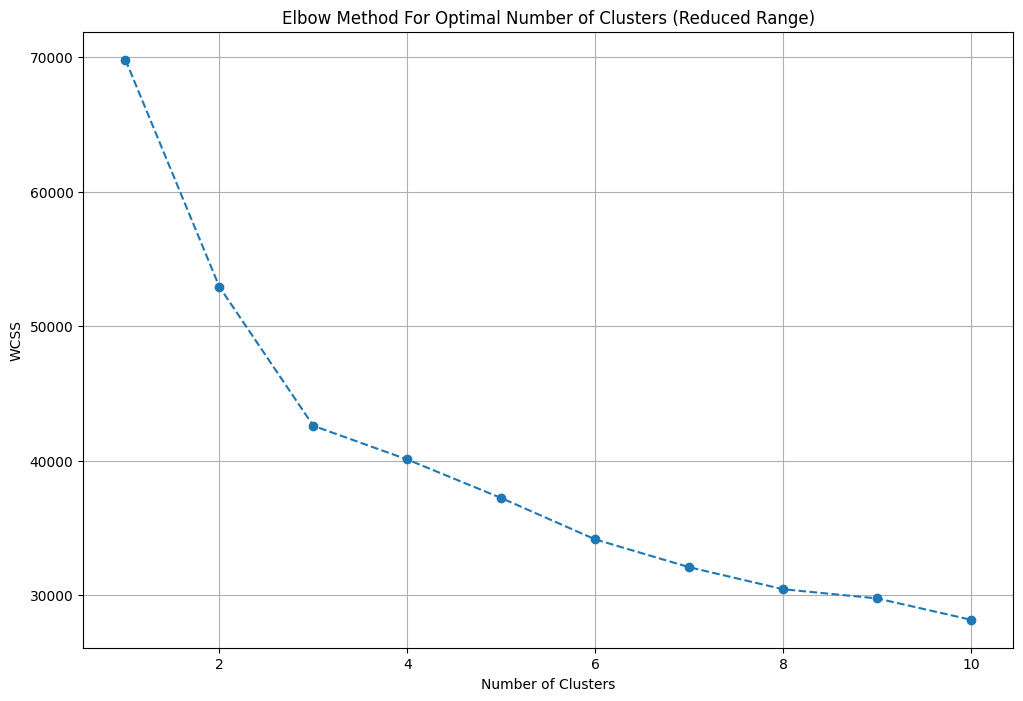

In [172]:
plt.figure(figsize=(12,8))
plt.plot(range(1,11),wcss_reduced,marker='o',linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [173]:
Kmeans=KMeans(n_clusters=3,random_state=42)
Kmeans.fit(scaled_data)
cluster_assignments=Kmeans.predict(scaled_data)

In [174]:
df.shape

(3878, 43)

In [175]:
df['furnishing_type']=cluster_assignments

In [176]:
df.shape

(3878, 44)

In [177]:
df

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,Sofa,TV,Fridge,Dining Table,Curtains,Modular Kitchen,Stove,Washing Machine,Wardrobe,furnishing_type
0,flat,gls avenue,sector 92,0.21,6953.0,302.00,Carpet area: 302 (28.06 sq.m.),1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,flat,paras quartier,sector 59,5.90,11028.0,5350.00,Built Up area: 5350 (497.03 sq.m.),4,4,3+,...,0,0,0,0,0,0,0,0,0,0
2,flat,hsiidc sidco aravali,sector 1,0.90,3477.0,2588.40,Super Built up area 2588(240.43 sq.m.)Built Up...,3,3,3+,...,0,0,0,0,0,0,0,0,0,0
3,house,sector 15 part 2 rwa,sector 15,10.00,22222.0,4520.84,Plot area 502(419.74 sq.m.),5,5,2,...,0,0,0,0,0,0,0,0,0,0
4,flat,eldeco accolade,sector 48,0.72,4975.0,1447.20,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3873,flat,bestech park view grand spa,sector 81,2.35,8834.0,2660.20,Super Built up area 2660(247.12 sq.m.)Carpet a...,3,4,3+,...,0,0,0,0,0,1,0,0,5,2
3874,flat,mm heights,sector 65,2.10,16653.0,1261.00,Super Built up area 1261(117.15 sq.m.)Carpet a...,2,2,3,...,0,0,0,0,0,0,0,0,0,0
3875,flat,vipul belmonte,sector 53,6.00,24489.0,2450.10,Super Built up area 2450(227.61 sq.m.),3,4,3+,...,0,0,0,0,0,1,0,0,3,2
3876,flat,corona gracieux,sector 76,1.05,5949.0,1765.00,Super Built up area 1765(163.97 sq.m.),3,3,3+,...,0,0,0,0,0,1,0,0,4,2


In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3878 entries, 0 to 3877
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3878 non-null   object 
 1   society              3877 non-null   object 
 2   sector               3878 non-null   object 
 3   price                3877 non-null   float64
 4   price_per_sqft       3877 non-null   float64
 5   area                 3877 non-null   float64
 6   areaWithType         3878 non-null   object 
 7   bedRoom              3878 non-null   int64  
 8   bathroom             3878 non-null   int64  
 9   balcony              3878 non-null   object 
 10  additionalRoom       3878 non-null   object 
 11  floorNum             3876 non-null   float64
 12  facing               2737 non-null   object 
 13  agePossession        3878 non-null   object 
 14  nearbyLocations      3686 non-null   object 
 15  furnishDetails       2869 non-null   o

In [179]:
df.sample(5)[['furnishDetails','furnishing_type']]

,furnishDetails,furnishing_type
114,"['9 Wardrobe', '24 Fan', '1 Exhaust Fan', '9 G...",2
3358,"['1 Wardrobe', '1 Fan', '1 Light', 'No AC', 'N...",0
854,NaN,0
828,"['1 Water Purifier', '1 Exhaust Fan', '3 AC', ...",0
2793,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No C...",0


In [180]:
df['furnishing_type'].value_counts()
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished 

furnishing_type
0    2601
2    1064
1     213
Name: count, dtype: int64

# features

In [181]:
df[['society','features']].sample(5)

,society,features
3455,vatika sovereign next,"['Security / Fire Alarm', 'Power Back-up', 'Pr..."
3375,independent,NaN
46,shapoorji pallonji joyville gurugram,"['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
1856,unitech escape,NaN
1503,unitech espace,"['Feng Shui / Vaastu Compliant', 'High Ceiling..."


In [182]:
df['features'].isnull().sum()

np.int64(681)

In [183]:
df.shape

(3878, 44)

In [184]:
import pandas as pd 
app_df=pd.read_csv('real_estate_data - real_estate_data.csv')
app_df.head()

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."
2,Adani Brahma Samsara Vilasa,"Land, 3, 4 BHK Independent Floor in Sector 63,...","['AIPL Business Club Sector 62', 'Heritage Xpe...","{'AIPL Business Club Sector 62': '2.7 Km', 'He...",https://www.99acres.com/adani-brahma-samsara-v...,{'3 BHK': {'building_type': 'Independent Floor...,"['Terrace Garden', 'Gazebo', 'Fountain', 'Amph..."
3,Sobha City,"2, 3, 4 BHK Apartment in Sector 108, Gurgaon","['The Shikshiyan School', 'WTC Plaza', 'Luxus ...","{'The Shikshiyan School': '2.9 KM', 'WTC Plaza...",https://www.99acres.com/sobha-city-sector-108-...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Volley Ball Court', 'Aerobi..."
4,Signature Global City 93,"2, 3 BHK Independent Floor in Sector 93 Gurgaon","['Pranavananda Int. School', 'DLF Site central...","{'Pranavananda Int. School': '450 m', 'DLF Sit...",https://www.99acres.com/signature-global-city-...,{'2 BHK': {'building_type': 'Independent Floor...,"['Mini Theatre', 'Doctor on Call', 'Concierge ..."


In [185]:
app_df['PropertyName']=app_df['PropertyName'].str.lower()

In [186]:
temp_df=df[df['features'].isnull()]

In [187]:
temp_df.shape

(681, 44)

In [188]:
x=temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [189]:
df.loc[temp_df.index,'features']=x.values

In [190]:
x

0      ['Mini Theatre', 'Swimming Pool', 'Business Lo...
1                                                    NaN
2                                                    NaN
3                                                    NaN
4                                                    NaN
                             ...                        
676                                                  NaN
677    ['Swimming Pool', 'Gazebo', 'Amphitheatre', 'B...
678                                                  NaN
679    ['Swimming Pool', 'Community Hall', 'Yoga/Medi...
680    ['Swimming Pool', 'Gazebo', 'Amphitheatre', 'B...
Name: TopFacilities, Length: 681, dtype: object

In [191]:
df['features'].isnull().sum()

np.int64(546)

In [192]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [193]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list']=df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else[])
# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix=mlb.fit_transform(df['features_list'])
# Convert the binary matrix into a DataFrame
features_binary_df=pd.DataFrame(features_binary_matrix,columns=mlb.classes_)

In [194]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Airy Rooms,Amphitheatre,Badminton Court,Bank Attached Property,Banquet Hall,...,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
440,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3160,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,1,0,1,0,0
1844,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2824,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2499,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,1,0,1,0,0


In [195]:
features_binary_df.shape

(3878, 123)

In [196]:
wcss_reduced=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

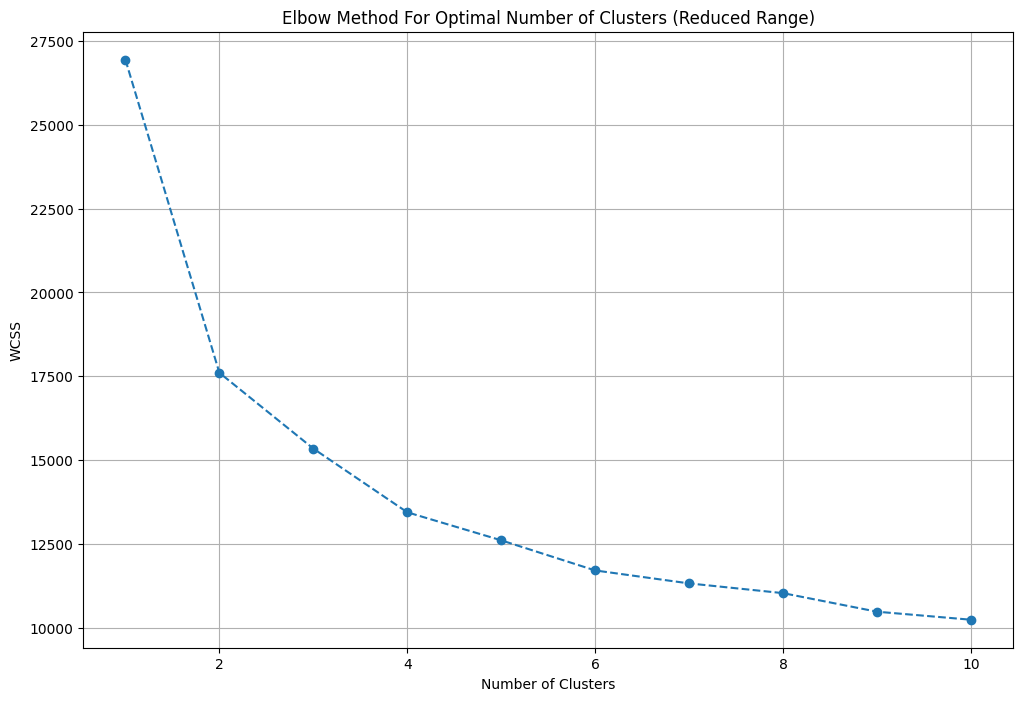

In [197]:
plt.figure(figsize=(12,8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [198]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
#calculate luxury score for each row
luxury_score=features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [199]:
df['luxury_score']=luxury_score

In [200]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,Fridge,Dining Table,Curtains,Modular Kitchen,Stove,Washing Machine,Wardrobe,furnishing_type,features_list,luxury_score
0,flat,gls avenue,sector 92,0.21,6953.0,302.00,Carpet area: 302 (28.06 sq.m.),1,1,1,...,0,0,0,0,0,0,0,0,"[Power Back-up, Feng Shui / Vaastu Compliant, ...",63
1,flat,paras quartier,sector 59,5.90,11028.0,5350.00,Built Up area: 5350 (497.03 sq.m.),4,4,3+,...,0,0,0,0,0,0,0,0,"[Mini Theatre, Swimming Pool, Business Lounge,...",63
2,flat,hsiidc sidco aravali,sector 1,0.90,3477.0,2588.40,Super Built up area 2588(240.43 sq.m.)Built Up...,3,3,3+,...,0,0,0,0,0,0,0,0,"[Lift(s), Maintenance Staff, Park, Piped-gas, ...",23
3,house,sector 15 part 2 rwa,sector 15,10.00,22222.0,4520.84,Plot area 502(419.74 sq.m.),5,5,2,...,0,0,0,0,0,0,0,0,"[Feng Shui / Vaastu Compliant, Private Garden ...",49
4,flat,eldeco accolade,sector 48,0.72,4975.0,1447.20,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,...,0,0,0,0,0,0,0,0,"[Centrally Air Conditioned, Water purifier, Se...",152


In [201]:
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [202]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,TV,Fridge,Dining Table,Curtains,Modular Kitchen,Stove,Washing Machine,Wardrobe,furnishing_type,luxury_score
70,flat,tulip violet,sector 69,1.29,8227.0,1568.00,Super Built up area 1568(145.67 sq.m.),3,3,1,...,0,0,0,0,1,0,0,2,2,86
3626,house,independent,sector 13,0.90,11464.0,785.76,Plot area 785(72.93 sq.m.),5,4,3,...,0,0,0,0,0,0,0,0,0,0
2532,flat,avl gurgaon,sector 36,0.75,7500.0,1000.00,Super Built up area 1000(92.9 sq.m.)Carpet are...,2,2,2,...,0,0,0,3,1,0,0,1,0,26
2222,flat,hero homes,sector 106,1.60,7825.0,2044.70,Super Built up area 1689(156.91 sq.m.),3,3,3,...,0,0,0,0,1,0,0,2,0,49
2678,flat,emaar palm gardens,sector 83,1.35,12325.0,1095.30,Super Built up area 1720(159.79 sq.m.)Carpet a...,3,3,3,...,0,0,0,0,0,0,0,0,0,24


In [203]:
df[df['society']=='hcbs sports ville']

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,TV,Fridge,Dining Table,Curtains,Modular Kitchen,Stove,Washing Machine,Wardrobe,furnishing_type,luxury_score
129,flat,hcbs sports ville,sector 48,0.29,5587.0,519.1,Carpet area: 519 (48.22 sq.m.),2,2,1,...,0,0,0,0,0,0,0,0,0,44
281,flat,hcbs sports ville,sector 48,0.20,4219.0,474.0,Built Up area: 473.99 (44.04 sq.m.),1,1,1,...,0,0,0,0,0,0,0,0,0,71
504,flat,hcbs sports ville,sector 48,0.28,3768.0,743.1,Built Up area: 743 (69.03 sq.m.)Carpet area: 6...,2,2,1,...,0,0,0,0,0,0,0,0,0,38
793,flat,hcbs sports ville,sector 48,0.22,3142.0,700.2,Carpet area: 700 (65.03 sq.m.),1,1,1,...,0,0,0,0,1,0,0,0,0,86
842,flat,hcbs sports ville,sector 48,0.32,5517.0,580.0,Carpet area: 580 (53.88 sq.m.),2,2,1,...,0,0,0,0,0,0,0,0,0,37
904,flat,hcbs sports ville,sector 48,0.32,6165.0,519.1,Carpet area: 519 (48.22 sq.m.),2,2,2,...,0,0,0,0,0,0,0,0,0,37
1435,flat,hcbs sports ville,sector 48,0.38,5067.0,750.0,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,2,2,2,...,0,0,0,0,0,0,0,0,0,0
1840,flat,hcbs sports ville,sector 48,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,...,1,1,0,1,1,1,1,1,1,44
1890,flat,hcbs sports ville,sector 48,0.22,4603.0,478.0,Built Up area: 477.85 (44.39 sq.m.)Carpet area...,1,1,1,...,0,1,0,8,1,0,0,1,2,44
1899,flat,hcbs sports ville,sector 2,0.35,4375.0,800.0,Built Up area: 800 (74.32 sq.m.)Carpet area: 6...,2,2,2,...,0,0,0,0,0,0,0,0,0,37


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3878 entries, 0 to 3877
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3878 non-null   object 
 1   society              3877 non-null   object 
 2   sector               3878 non-null   object 
 3   price                3877 non-null   float64
 4   price_per_sqft       3877 non-null   float64
 5   area                 3877 non-null   float64
 6   areaWithType         3878 non-null   object 
 7   bedRoom              3878 non-null   int64  
 8   bathroom             3878 non-null   int64  
 9   balcony              3878 non-null   object 
 10  floorNum             3876 non-null   float64
 11  facing               2737 non-null   object 
 12  agePossession        3878 non-null   object 
 13  super_built_up_area  1924 non-null   float64
 14  built_up_area        1787 non-null   float64
 15  carpet_area          1975 non-null   f

In [205]:
df.duplicated().sum()

np.int64(128)

In [206]:
df=df.drop_duplicates()

In [207]:
df.to_csv('gurgaon_properties_cleaned2_v2.csv',index=False)